In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

from sklearn.metrics import class_likelihood_ratios, recall_score, precision_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1)

from likelihood_ratios import calc_likelihood_ratios

In [19]:
bootstrap_columns = [f"target_bootstrap_{n}" for n in range(1000)]

<Axes: >

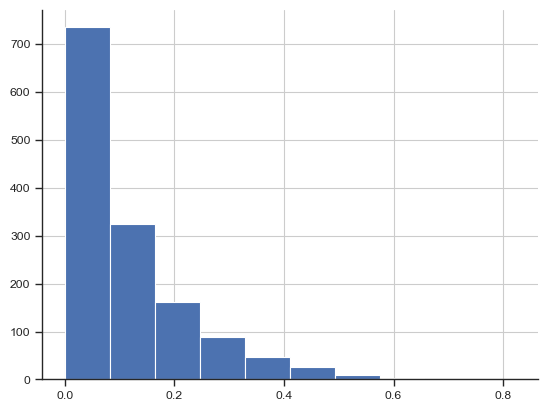

In [20]:
mort_results = pd.read_csv(
    "mort_bootstrap_results_df.csv",
    #sep="\t",
)
mort_results["30 Day Mortality"].hist()

In [22]:
mort_sensitivity = recall_score(
    mort_results['survival_30_day'],
    np.where(mort_results['30 Day Mortality'] > 0, 1, 0)
)
mort_sensitivity

0.8190045248868778

In [23]:


mort_bs_df, mort_lr_df = calc_likelihood_ratios(
    mort_results,
    "survival_30_day",
    "30 Day Mortality",
    [0.0, 0.1, 0.2, 0.3, 0.4],
    bootstrap_columns,
)

<Axes: >

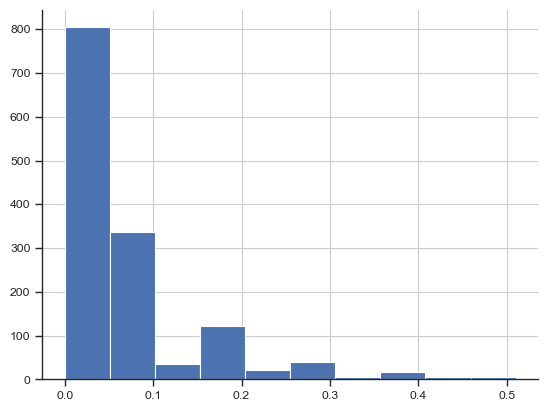

In [24]:
vaso_results = pd.read_csv(
    "vaso_bootstrap_results_df.csv",
    #sep="\t",
)
vaso_results["Vaso"].hist()

In [25]:
vaso_sensitivity = recall_score(
    vaso_results['vasopressor_treatment'],
    np.where(vaso_results['Vaso'] > 0, 1, 0)
)
vaso_sensitivity

0.8448275862068966

In [26]:


vaso_bs_df, vaso_lr_df = calc_likelihood_ratios(
    vaso_results,
    "vasopressor_treatment",
    "Vaso",
    [0.0, 0.1, 0.2, 0.3, 0.4],
    bootstrap_columns,
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)


<Axes: >

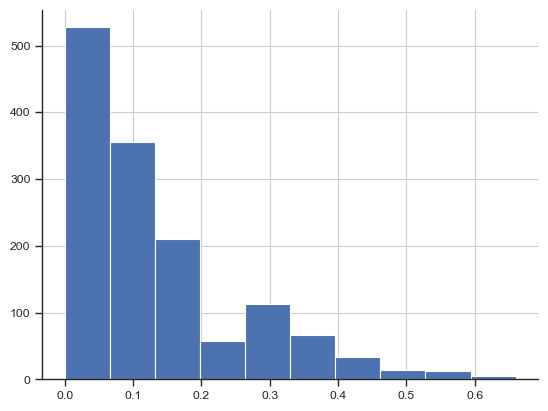

In [27]:
albumin_results = pd.read_csv(
    "albumin_bootstrap_results_df.csv",
    #sep="\t",
)

albumin_results['albumin_treatment'] = albumin_results['albumin_treatment'].fillna(0.0)

albumin_results["Albumin"].hist()

In [28]:
albumin_sensitivity = recall_score(
    albumin_results['albumin_treatment'],
    np.where(albumin_results['Albumin'] > 0, 1, 0)
)
albumin_sensitivity

0.9035087719298246

In [29]:
albumin_results = pd.read_csv(
    "albumin_bootstrap_results_df.csv",
    #sep="\t",
)

albumin_results['albumin_treatment'] = albumin_results['albumin_treatment'].fillna(0.0)

albumin_bs_df, albumin_lr_df = calc_likelihood_ratios(
    albumin_results,
    "albumin_treatment",
    "Albumin",
    [0.0, 0.1, 0.2, 0.3, 0.4],
    bootstrap_columns,
)

<Axes: >

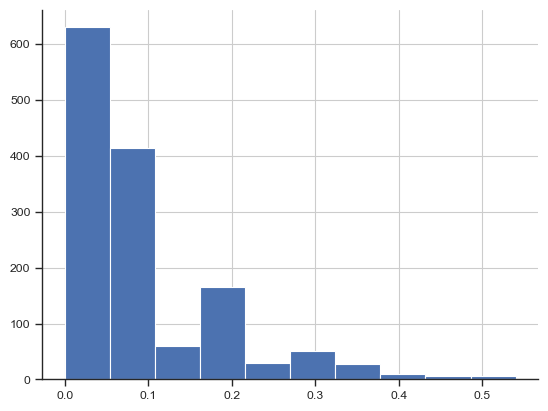

In [30]:
icu_results = pd.read_csv(
    "icu_bootstrap_results_df.csv",
    #sep="\t",
)

icu_results["critical_care"] = icu_results["critical_care"].fillna(0)
icu_results["ICU"].hist()


In [31]:
icu_sensitivity = recall_score(
    icu_results['critical_care'],
    np.where(icu_results['ICU'] > 0, 1, 0)
)
icu_sensitivity

0.8235294117647058

In [32]:


icu_bs_df, icu_lr_df = calc_likelihood_ratios(
    icu_results,
    "critical_care",
    "ICU",
    [0.0, 0.1, 0.2, 0.3, 0.4],
    bootstrap_columns,
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)


/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_58075/3443229404.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


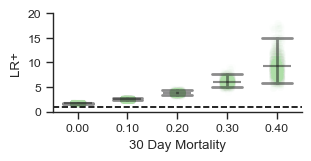

In [33]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    #width_ratios=[0.25, 1],
    constrained_layout=True,
    #sharey="row",
)

sns.pointplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs,
    alpha=0.5,
)

sns.stripplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#AEDEA7",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1,

)

axs.set_xlabel("Cutoff\n30 Day Mortality")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.2f}" for val in mort_lr_df['Cutoff']],
)
axs.set_ylim(0, 20)

axs.set_xlabel("30 Day Mortality")
#axs[1].set_title("Organ Dysfunction")


fig.set_size_inches(
    (3, 1.5)
)

fig.savefig("mortality_metrics.pdf", bbox_inches="tight", dpi=300, transparent=True)


/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_58075/3704530631.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


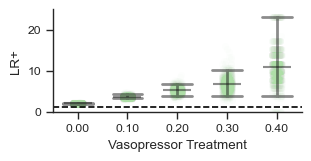

In [34]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    #width_ratios=[0.25, 1],
    constrained_layout=True,
    #sharey="row",
)

sns.pointplot(
    data=vaso_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs,
    alpha=0.5,
)

sns.stripplot(
    data=vaso_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#AEDEA7",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1

)

axs.set_xlabel("Cutoff\nVasopressor\nTreatment")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.2f}" for val in mort_lr_df['Cutoff']],
)
axs.set_ylim(0, 25)

axs.set_xlabel("Vasopressor Treatment")
#axs[1].set_title("Organ Dysfunction")


fig.set_size_inches(
    (3, 1.5)
)

fig.savefig("vasopressor_metrics.pdf", bbox_inches="tight", dpi=300, transparent=True)


/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_58075/3961660229.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


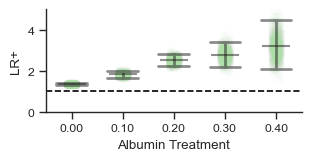

In [35]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    #width_ratios=[0.25, 1],
    constrained_layout=True,
    #sharey="row",
)

sns.pointplot(
    data=albumin_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs,
    alpha=0.5,
)

sns.stripplot(
    data=albumin_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#AEDEA7",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1

)

axs.set_xlabel("Cutoff\nAlbumin")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.2f}" for val in mort_lr_df['Cutoff']],
)
axs.set_ylim(0, 5)

axs.set_xlabel("Albumin Treatment")
#axs[1].set_title("Organ Dysfunction")


fig.set_size_inches(
    (3, 1.5)
)

fig.savefig("albumin_metrics.pdf", bbox_inches="tight", dpi=300, transparent=True)


/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_58075/2502346159.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(


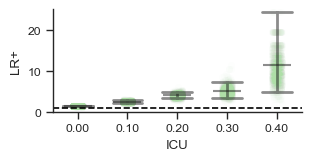

In [36]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    #width_ratios=[0.25, 1],
    constrained_layout=True,
    #sharey="row",
)

sns.pointplot(
    data=icu_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs,
    alpha=0.5,
)

sns.stripplot(
    data=icu_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs,
    color="#AEDEA7",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1

)

axs.set_xlabel("ICU")

axs.axhline(y=1, linestyle='--', color='black')
axs.set_xticklabels(
    [f"{val:.2f}" for val in icu_lr_df['Cutoff']],
)
axs.set_ylim(0, 25)
#axs[1].set_title("Organ Dysfunction")


fig.set_size_inches(
    (3, 1.5)
)

fig.savefig("icu_metrics.pdf", bbox_inches="tight", dpi=300, transparent=True)


In [37]:
combined_auc = pd.concat(
    [mort_bs_df, icu_bs_df, albumin_bs_df, vaso_bs_df],
    ignore_index=True,
)

In [38]:
combined_auc

,Recall,AUC,Label
0,0.723982,0.692926,30 Day Mortality
1,0.723982,0.694774,30 Day Mortality
2,0.746606,0.701866,30 Day Mortality
3,0.714932,0.688239,30 Day Mortality
4,0.746606,0.703562,30 Day Mortality
...,...,...,...
3995,0.775862,0.750889,Vaso
3996,0.758621,0.742520,Vaso
3997,0.793103,0.752874,Vaso
3998,0.758621,0.742107,Vaso


In [40]:
sensitivity_df = pd.DataFrame(
    {
        "Label": ["30 Day Mortality", "ICU", "Albumin Treatment", "Vasopressor Treatment"],
        "Recall": [mort_sensitivity, icu_sensitivity, albumin_sensitivity, vaso_sensitivity],
    }
)

In [46]:
sensitivity_df

,Label,Recall
0,30 Day Mortality,0.819005
1,ICU,0.823529
2,Albumin Treatment,0.903509
3,Vasopressor Treatment,0.844828


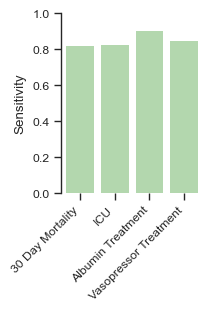

In [48]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    #width_ratios=[0.25, 1],
    constrained_layout=True,
    #sharey="row",
)

sns.barplot(
    data=sensitivity_df,
    x="Label",
    y="Recall",
    #hue="Label",
    color="#AEDEA7",
    ax=axs,
    #palette="Blues",
    linewidth=0,
    legend=False,
    #alpha=0.02,
    zorder=1
)

axs.set_xlabel("")
axs.set_ylabel("Sensitivity")

axs.set_ylim(0, 1)


plt.xticks(rotation=45, ha="right")

fig.set_size_inches(
    (2, 3)
)
sns.despine(ax=axs, bottom=True, top=True, trim=True, offset=1)

fig.savefig(
    "sensitive_metrics.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

In [49]:
sensitivity_df

,Label,Recall
0,30 Day Mortality,0.819005
1,ICU,0.823529
2,Albumin Treatment,0.903509
3,Vasopressor Treatment,0.844828


In [ ]:
a